<a href="https://colab.research.google.com/github/carolembomegni/Projet_SD_Detection_Tumeurs/blob/Willy-Projet/normalisation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import gdown
import zipfile
import os

file_id = "1PIRDtyfUM3prHQKm_tdfw_-5bGeVDJTc"
url = f"https://drive.google.com/uc?id={file_id}"

output = "dataset.zip"

gdown.download(url, output, quiet=False)

with zipfile.ZipFile(output, 'r') as zip_ref:
    zip_ref.extractall("/content/")

# Détection du dossier dataset
possible_dirs = [d for d in os.listdir("/content") if "brain" in d.lower()]

if len(possible_dirs) > 0:
    DATA_PATH = f"/content/{possible_dirs[0]}"
else:
    raise Exception("Dataset folder not found")

print("DATA_PATH =", DATA_PATH)

Downloading...
From (original): https://drive.google.com/uc?id=1PIRDtyfUM3prHQKm_tdfw_-5bGeVDJTc
From (redirected): https://drive.google.com/uc?id=1PIRDtyfUM3prHQKm_tdfw_-5bGeVDJTc&confirm=t&uuid=3b3182cc-2d13-4733-8f27-10be42aee6fc
To: /content/dataset.zip
100%|██████████| 94.3M/94.3M [00:01<00:00, 81.4MB/s]


DATA_PATH = /content/brain-tumor-classification-mri


In [2]:
import os
import shutil
from pathlib import Path

# =====================================
# CHEMINS
# =====================================
src_root = Path(DATA_PATH)      # chemin détecté automatiquement par le bloc d'import
dst_root = Path("/content/Binary")

splits = ["Training", "Testing"]
tumor_folders = ["glioma_tumor", "meningioma_tumor", "pituitary_tumor"]
no_tumor_folder = "no_tumor"

# =====================================
# NETTOYAGE SI LE DOSSIER EXISTE DEJA
# =====================================
if dst_root.exists():
    shutil.rmtree(dst_root)

# =====================================
# CREATION DES DOSSIERS DE DESTINATION
# =====================================
for split in splits:
    (dst_root / split / "tumor").mkdir(parents=True, exist_ok=True)
    (dst_root / split / "no_tumor").mkdir(parents=True, exist_ok=True)

# =====================================
# FONCTION DE COPIE SECURISEE
# =====================================
def safe_copy(src_file: Path, dst_dir: Path):
    dst_file = dst_dir / src_file.name
    if dst_file.exists():
        dst_file = dst_dir / f"{src_file.stem}_{abs(hash(str(src_file))) % 10**8}{src_file.suffix}"
    shutil.copy2(src_file, dst_file)

# =====================================
# FUSION DES CLASSES EN BINAIRE
# =====================================
for split in splits:
    # Fusion des classes tumor
    for cls in tumor_folders:
        cls_path = src_root / split / cls
        if cls_path.exists():
            for img in cls_path.rglob("*"):
                if img.is_file():
                    safe_copy(img, dst_root / split / "tumor")

    # Copie de la classe no_tumor
    cls_path = src_root / split / no_tumor_folder
    if cls_path.exists():
        for img in cls_path.rglob("*"):
            if img.is_file():
                safe_copy(img, dst_root / split / "no_tumor")

# =====================================
# VERIFICATION
# =====================================
print("✅ Fusion binaire terminée.")
print("Dossier source :", src_root)

print("\nTraining classes :", os.listdir(dst_root / "Training"))
print("Testing classes  :", os.listdir(dst_root / "Testing"))

print("\nNombre d'images Training/tumor    :", len(list((dst_root / "Training" / "tumor").glob("*"))))
print("Nombre d'images Training/no_tumor :", len(list((dst_root / "Training" / "no_tumor").glob("*"))))
print("Nombre d'images Testing/tumor     :", len(list((dst_root / "Testing" / "tumor").glob("*"))))
print("Nombre d'images Testing/no_tumor  :", len(list((dst_root / "Testing" / "no_tumor").glob("*"))))

✅ Fusion binaire terminée.
Dossier source : /content/brain-tumor-classification-mri

Training classes : ['tumor', 'no_tumor']
Testing classes  : ['tumor', 'no_tumor']

Nombre d'images Training/tumor    : 2475
Nombre d'images Training/no_tumor : 395
Nombre d'images Testing/tumor     : 289
Nombre d'images Testing/no_tumor  : 105


In [3]:
import tensorflow as tf
import os

# ==============================
# CHEMINS DU DATASET BINAIRE
# ==============================
train_dir = "/content/Binary/Training"
test_dir  = "/content/Binary/Testing"

print("Classes train :", os.listdir(train_dir))
print("Classes test  :", os.listdir(test_dir))

# ==============================
# CHARGEMENT DU DATASET TRAIN
# ==============================
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(224, 224),
    batch_size=32,
    label_mode='binary',
    shuffle=True,
    seed=42
)

# ==============================
# CHARGEMENT DU DATASET TEST
# ==============================
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(224, 224),
    batch_size=32,
    label_mode='binary',
    shuffle=False
)

Classes train : ['tumor', 'no_tumor']
Classes test  : ['tumor', 'no_tumor']
Found 2870 files belonging to 2 classes.
Found 394 files belonging to 2 classes.


In [4]:
from PIL import Image
from pathlib import Path

# ==============================
# CHEMINS DU DATASET BINAIRE
# ==============================
train_dir = Path("/content/Binary/Training")
test_dir  = Path("/content/Binary/Testing")

# ==============================
# FONCTION SUPPRESSION IMAGES CORROMPUES
# ==============================
def remove_corrupted_images(folder):
    removed = 0
    for img_path in folder.rglob("*"):
        if img_path.is_file():
            try:
                with Image.open(img_path) as img:
                    img.verify()
            except Exception:
                print("❌ Image corrompue supprimée :", img_path)
                img_path.unlink()
                removed += 1
    return removed

# ==============================
# EXECUTION
# ==============================
removed_train = remove_corrupted_images(train_dir)
removed_test  = remove_corrupted_images(test_dir)

print("\n✅ Nettoyage terminé")
print("Images supprimées - Training :", removed_train)
print("Images supprimées - Testing  :", removed_test)


✅ Nettoyage terminé
Images supprimées - Training : 0
Images supprimées - Testing  : 0


In [5]:
# Equilibrer le data  d entrainement
import shutil
import numpy as np
from pathlib import Path
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array, save_img

# =====================================
# DOSSIERS SOURCE
# =====================================
train_no = Path("/content/Binary/Training/no_tumor")
train_tu = Path("/content/Binary/Training/tumor")

# =====================================
# DOSSIERS DESTINATION EQUILIBRES
# =====================================
balanced_root = Path("/content/Binary/Training_balanced")
balanced_no = balanced_root / "no_tumor"
balanced_tu = balanced_root / "tumor"

# Nettoyage si le dossier existe déjà
if balanced_root.exists():
    shutil.rmtree(balanced_root)

balanced_no.mkdir(parents=True, exist_ok=True)
balanced_tu.mkdir(parents=True, exist_ok=True)

# =====================================
# LISTE DES IMAGES
# =====================================
no_files = list(train_no.glob("*"))
tu_files = list(train_tu.glob("*"))

n_no = len(no_files)
n_tu = len(tu_files)

print("Nombre initial no_tumor :", n_no)
print("Nombre initial tumor    :", n_tu)

# =====================================
# COPIE DES IMAGES ORIGINALES
# =====================================
for f in no_files:
    shutil.copy2(f, balanced_no / f.name)

for f in tu_files:
    shutil.copy2(f, balanced_tu / f.name)

# =====================================
# DATA AUGMENTATION
# =====================================
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    horizontal_flip=True,
    fill_mode='nearest'
)

# =====================================
# FONCTION POUR GENERER JUSQU'A EQUILIBRE
# =====================================
def augment_until_target(files, output_dir, target_count, prefix):
    current_count = len(list(output_dir.glob("*")))
    i = 0

    while current_count < target_count:
        img_path = files[i % len(files)]
        img = load_img(img_path, target_size=(224, 224))
        x = img_to_array(img)
        x = np.expand_dims(x, axis=0)

        aug_iter = datagen.flow(x, batch_size=1)

        aug_img = next(aug_iter)[0].astype("uint8")
        save_path = output_dir / f"{prefix}_aug_{current_count}.jpg"
        save_img(save_path, aug_img)

        current_count += 1
        i += 1

# =====================================
# EQUILIBRAGE
# =====================================
target = max(n_no, n_tu)

if n_no < target:
    augment_until_target(no_files, balanced_no, target, "no_tumor")

if n_tu < target:
    augment_until_target(tu_files, balanced_tu, target, "tumor")

print("\n✅ Equilibrage terminé")
print("no_tumor final :", len(list(balanced_no.glob('*'))))
print("tumor final    :", len(list(balanced_tu.glob('*'))))

Nombre initial no_tumor : 395
Nombre initial tumor    : 2475

✅ Equilibrage terminé
no_tumor final : 2475
tumor final    : 2475


In [8]:
# Charger le ytrain equilibre plus test
import tensorflow as tf
import os

balanced_train_dir = "/content/Binary/Training_balanced"
test_dir = "/content/Binary/Testing"

print("Classes train équilibré :", os.listdir(balanced_train_dir))
print("Classes test            :", os.listdir(test_dir))

Classes train équilibré : ['tumor', 'no_tumor']
Classes test            : ['tumor', 'no_tumor']


In [9]:
# Créer train et validation à partir du train équilibré
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    balanced_train_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    balanced_train_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=True
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=False
)

print("Noms des classes :", train_ds.class_names)

Found 4950 files belonging to 2 classes.
Using 3960 files for training.
Found 4950 files belonging to 2 classes.
Using 990 files for validation.
Found 394 files belonging to 2 classes.
Noms des classes : ['no_tumor', 'tumor']


In [10]:
# Normalisation
import tensorflow as tf

AUTOTUNE = tf.data.AUTOTUNE

# ==============================
# COUCHE DE NORMALISATION
# ==============================
normalization_layer = tf.keras.layers.Rescaling(1./255)

# ==============================
# APPLICATION SUR LES DATASETS
# ==============================
train_ds = train_ds.map(
    lambda x, y: (normalization_layer(x), y),
    num_parallel_calls=AUTOTUNE
)

val_ds = val_ds.map(
    lambda x, y: (normalization_layer(x), y),
    num_parallel_calls=AUTOTUNE
)

test_ds = test_ds.map(
    lambda x, y: (normalization_layer(x), y),
    num_parallel_calls=AUTOTUNE
)

# ==============================
# OPTIMISATION DU PIPELINE
# ==============================
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds  = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("✅ Normalisation terminée (pixels entre 0 et 1)")

✅ Normalisation terminée (pixels entre 0 et 1)


/tmp/ipykernel_4107/559467833.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(f"Label: {int(labels[i].numpy())}")


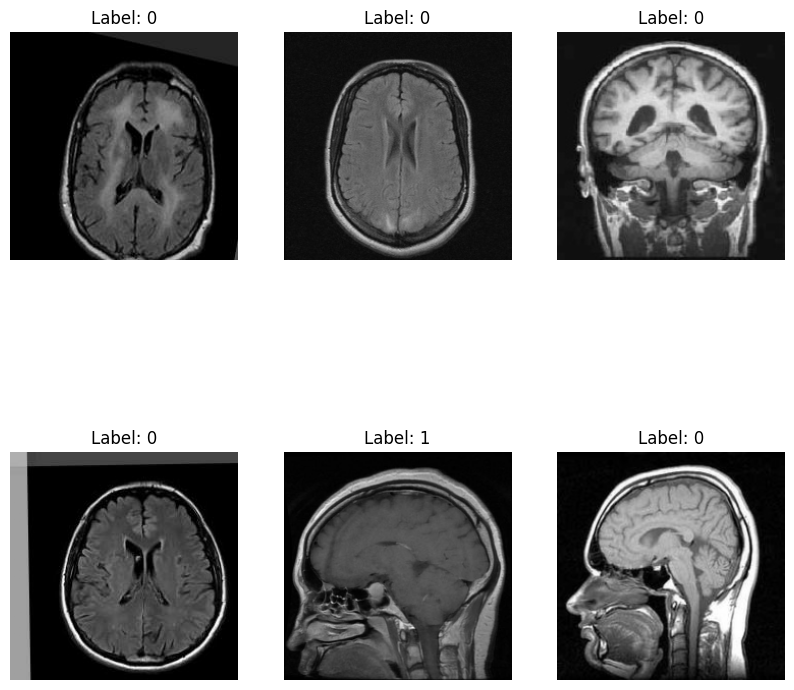

In [11]:
import matplotlib.pyplot as plt

for images, labels in train_ds.take(1):
    plt.figure(figsize=(10, 10))
    for i in range(6):
        ax = plt.subplot(2, 3, i + 1)
        plt.imshow(images[i].numpy())
        plt.title(f"Label: {int(labels[i].numpy())}")
        plt.axis("off")
    plt.show()